# Qualitative Risk Assessment
## Microsoft Cybersecurity Acquisition – Scenario Analytics & Industry Fusion Analytics

**Authors:** Honglin Wang, Chuanli Yang, Raymond Twumasi Opoku  
**Course:** ALY 6130 – Risk Management for Analytics  
**Date:** March 2026

---

### Purpose

This notebook provides the code-based implementation of the qualitative risk assessment for Microsoft's proposed cybersecurity platform acquisition. It applies two frameworks from Fleisher & Bensoussan (2015):

1. **Scenario Analytics** (Chapter 22) — Best-case, most-likely, and worst-case scenario modeling for each risk area.
2. **Industry Fusion Analytics** (Chapter 17) — Assessment of how converging industry forces influence risk exposure.

The notebook concludes with a candidacy assessment that determines which risks require further quantitative analysis.

**References:**
- Fleisher, C. S., & Bensoussan, B. E. (2015). *Business and competitive analysis* (2nd ed.). FT Press.
- COSO. (2017). *Enterprise risk management—Integrating with strategy and performance.*
- Hopkin, P. (2018). *Fundamentals of risk management* (5th ed.). Kogan Page.
- Fraser, J. R. S., & Simkins, B. J. (2016). The challenges of and solutions for implementing ERM. *Business Horizons, 59*(6), 689–698.

In [1]:
# ============================================================
# Section 1: Environment Setup and Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

# Load risk register
FILE_PATH = r'C:\Users\kevin\Desktop\New folder\aly-6130-microsoft--main\aly-6130-microsoft--main\Assignment4\risk_register_updated.xlsx'

df = pd.read_excel(FILE_PATH, sheet_name='Risk Register')
df.columns = [
    'No', 'Main_Risk_Area', 'Sub_Risk_Question',
    'Likelihood_Score', 'Impact_Score', 'Risk_Level', 'Extra',
    'Risk_Score', 'MC_Mean', 'MC_VaR_95', 'P_High',
    'IW_Composite', 'Warning_Level'
]
df = df.drop(columns=['Extra'])

area_map = {
    'Loss of Cybersecurity Market Share': 'Market Share Loss',
    'Critical Data Breach During Platform Integration': 'Data Breach',
    'Accelerated Enterprise Customer Acquisition Through Bundled Security Offerings': 'Enterprise Acq.'
}
df['Area'] = df['Main_Risk_Area'].map(area_map)

print(f'Loaded {len(df)} sub-risks for qualitative assessment.')

Loaded 40 sub-risks for qualitative assessment.


---
## Part 1: Scenario Analytics (Fleisher & Bensoussan, Ch. 22)

Scenario Analytics develops plausible future states for each risk area by defining **best-case**, **most-likely**, and **worst-case** outcomes along key dimensions. This structured approach avoids single-point estimation bias and surfaces the range of consequences that decision-makers must prepare for (Fleisher & Bensoussan, 2015).

In [2]:
# ============================================================
# Section 2: Define Scenario Parameters
# ============================================================

scenarios = {
    'Market Share Loss': {
        'dimensions': ['Competitive Win Rate', 'Customer Churn', 'Revenue Impact ($M)',
                       'Time to Parity (months)', 'Brand Perception Score (1-10)'],
        'best':       [0.55,  0.03,  50,   6,  8.5],
        'likely':     [0.40,  0.08, 150,  12,  6.0],
        'worst':      [0.25,  0.15, 400,  24,  3.5],
        'description': {
            'best': 'Microsoft leverages Azure ecosystem and brand to win >50% of contested deals; '
                    'acquired talent innovates rapidly; competitors lose enterprise accounts.',
            'likely': 'Mixed competitive outcomes; Microsoft wins mid-market deals but struggles '
                      'against CrowdStrike/Palo Alto in specialized segments; gradual market positioning.',
            'worst': 'Specialized competitors accelerate innovation; enterprise customers defect; '
                     'integration delays slow product releases; acquisition synergies unrealized.'
        }
    },
    'Data Breach': {
        'dimensions': ['Unresolved Vulnerabilities', 'Breach Probability (%)', 'Potential Fine ($M)',
                       'Recovery Time (months)', 'Customer Trust Impact (1-10)'],
        'best':       [  2,   5,    0,   0, 9.0],
        'likely':     [  8,  25,   50,   3, 6.0],
        'worst':      [ 25,  60,  800,  18, 2.0],
        'description': {
            'best': 'Phased integration proceeds smoothly; zero-trust controls contain all threats; '
                    'no public security incidents; customer confidence strengthened.',
            'likely': 'Minor security incidents detected and contained internally; some vulnerabilities '
                      'persist but are managed within acceptable thresholds; no public disclosure needed.',
            'worst': 'Major breach during active integration exposes customer data across multiple '
                     'jurisdictions; GDPR/CCPA penalties exceed $500M; existential trust crisis '
                     'for the cybersecurity brand; years of reputational recovery.'
        }
    },
    'Enterprise Acq.': {
        'dimensions': ['Pipeline Growth Rate (%/mo)', 'Bundle Attach Rate (%)', 'New Enterprise Clients',
                       'Revenue per Client ($K)', 'Time to Market (months)'],
        'best':       [  20,  45,  500, 350,  8],
        'likely':     [  12,  28,  250, 220, 14],
        'worst':      [   4,  10,   80, 120, 24],
        'description': {
            'best': 'First-mover advantage captured; integrated compliance-security suite launches '
                    'within 8 months; strong enterprise demand in healthcare, finance, and government.',
            'likely': 'Moderate adoption; product launches on schedule but faces competitive '
                      'counter-moves; pipeline grows steadily but below aggressive targets.',
            'worst': 'Technical delays push launch beyond 18 months; competitors form partnerships '
                     'to offer similar bundles; the competitive window closes before Microsoft captures share.'
        }
    }
}

print('Scenario parameters defined for 3 risk areas, 5 dimensions each.')
print('Scenarios: Best Case | Most Likely | Worst Case')

Scenario parameters defined for 3 risk areas, 5 dimensions each.
Scenarios: Best Case | Most Likely | Worst Case


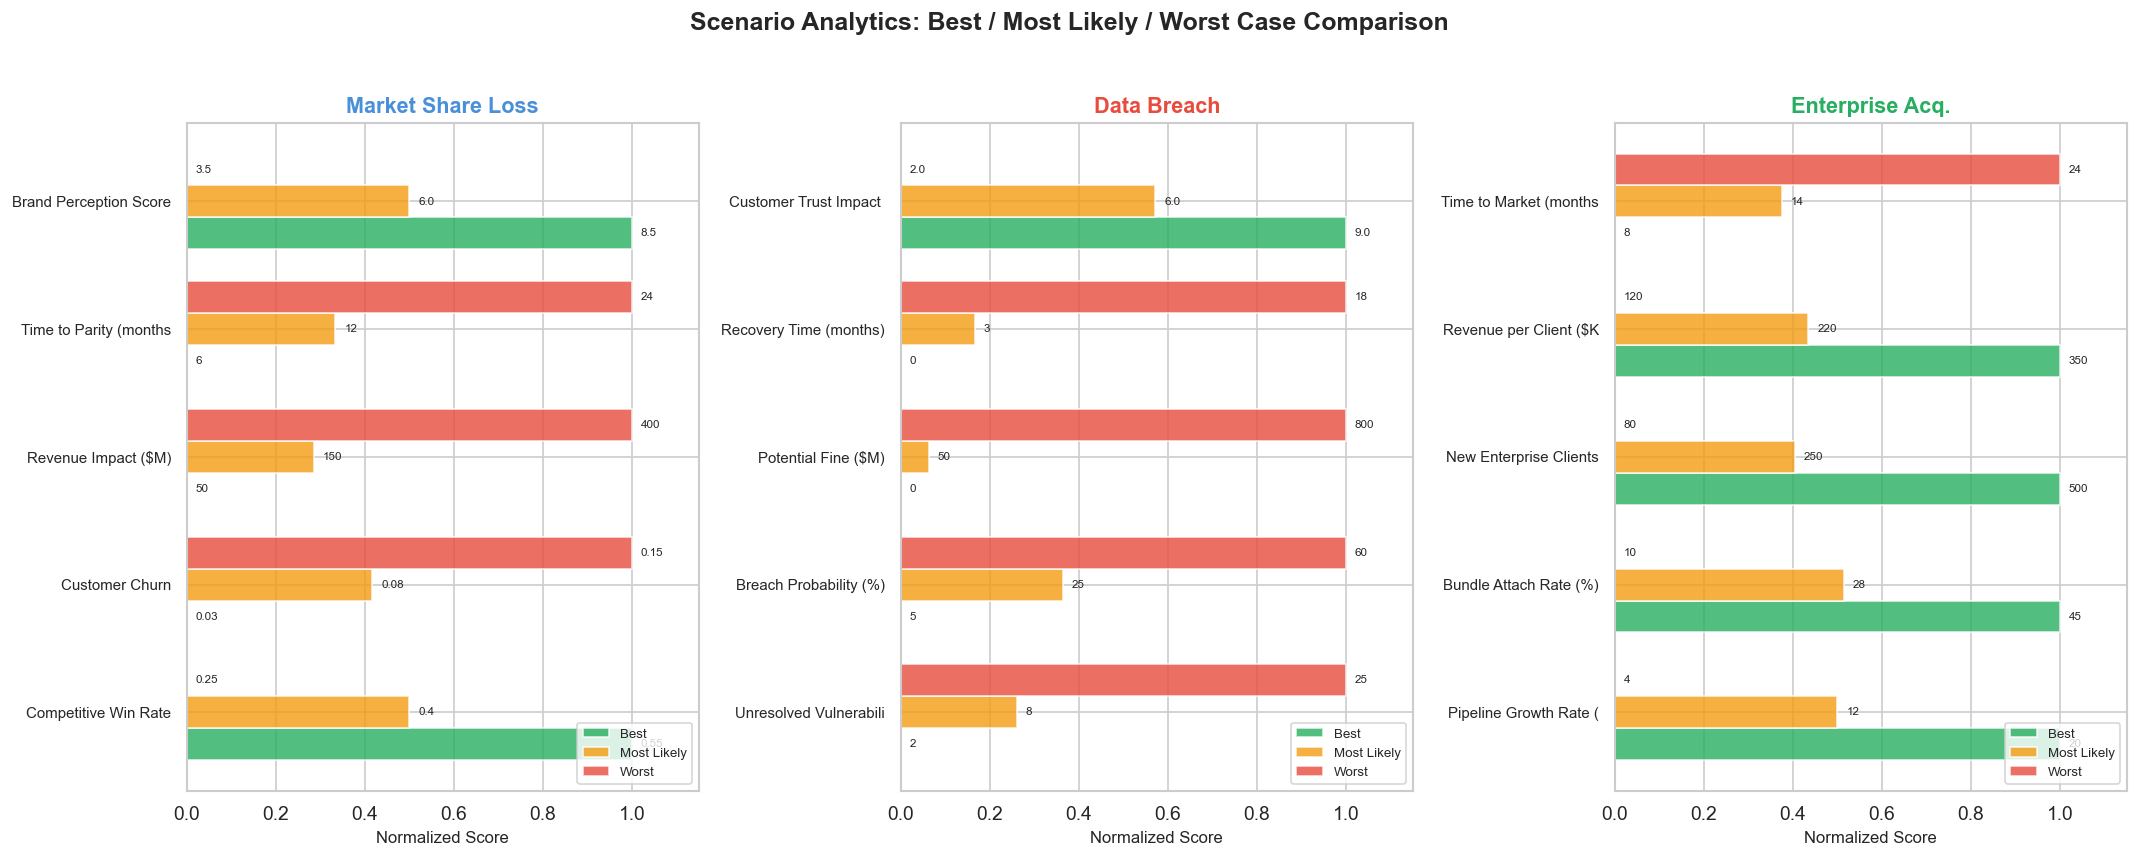

In [3]:
# ============================================================
# Section 3: Scenario Comparison Visualization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

area_keys = ['Market Share Loss', 'Data Breach', 'Enterprise Acq.']
area_colors = {'Market Share Loss': '#4A90D9', 'Data Breach': '#E74C3C', 'Enterprise Acq.': '#27AE60'}

for ax, area in zip(axes, area_keys):
    s = scenarios[area]
    dims = s['dimensions']
    n = len(dims)
    
    # Normalize all values to 0-1 scale for radar-style comparison
    best = np.array(s['best'], dtype=float)
    likely = np.array(s['likely'], dtype=float)
    worst = np.array(s['worst'], dtype=float)
    
    # Stack and normalize per dimension
    all_vals = np.vstack([best, likely, worst])
    mins = all_vals.min(axis=0)
    maxs = all_vals.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1  # avoid division by zero
    
    best_n = (best - mins) / ranges
    likely_n = (likely - mins) / ranges
    worst_n = (worst - mins) / ranges
    
    y = np.arange(n)
    ax.barh(y - 0.25, best_n, height=0.25, color='#27AE60', alpha=0.8, label='Best')
    ax.barh(y, likely_n, height=0.25, color='#F39C12', alpha=0.8, label='Most Likely')
    ax.barh(y + 0.25, worst_n, height=0.25, color='#E74C3C', alpha=0.8, label='Worst')
    
    ax.set_yticks(y)
    ax.set_yticklabels([d[:22] for d in dims], fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('Normalized Score', fontsize=10)
    ax.set_title(area, fontsize=13, fontweight='bold', color=area_colors[area])
    ax.legend(fontsize=8, loc='lower right')
    
    # Add raw values as annotations
    for i in range(n):
        ax.text(best_n[i] + 0.02, i - 0.25, f'{s["best"][i]}', va='center', fontsize=7)
        ax.text(likely_n[i] + 0.02, i, f'{s["likely"][i]}', va='center', fontsize=7)
        ax.text(worst_n[i] + 0.02, i + 0.25, f'{s["worst"][i]}', va='center', fontsize=7)

fig.suptitle('Scenario Analytics: Best / Most Likely / Worst Case Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Section 4: Scenario Narrative Summary
# ============================================================

for area in area_keys:
    print('='*70)
    print(f'SCENARIO ANALYTICS: {area.upper()}')
    print('='*70)
    for case in ['best', 'likely', 'worst']:
        label = {'best': 'BEST CASE', 'likely': 'MOST LIKELY', 'worst': 'WORST CASE'}[case]
        print(f'\n  [{label}]')
        print(f'  {scenarios[area]["description"][case]}')
        vals = scenarios[area][case]
        dims = scenarios[area]['dimensions']
        for d, v in zip(dims, vals):
            print(f'    • {d}: {v}')
    print()

SCENARIO ANALYTICS: MARKET SHARE LOSS

  [BEST CASE]
  Microsoft leverages Azure ecosystem and brand to win >50% of contested deals; acquired talent innovates rapidly; competitors lose enterprise accounts.
    • Competitive Win Rate: 0.55
    • Customer Churn: 0.03
    • Revenue Impact ($M): 50
    • Time to Parity (months): 6
    • Brand Perception Score (1-10): 8.5

  [MOST LIKELY]
  Mixed competitive outcomes; Microsoft wins mid-market deals but struggles against CrowdStrike/Palo Alto in specialized segments; gradual market positioning.
    • Competitive Win Rate: 0.4
    • Customer Churn: 0.08
    • Revenue Impact ($M): 150
    • Time to Parity (months): 12
    • Brand Perception Score (1-10): 6.0

  [WORST CASE]
  Specialized competitors accelerate innovation; enterprise customers defect; integration delays slow product releases; acquisition synergies unrealized.
    • Competitive Win Rate: 0.25
    • Customer Churn: 0.15
    • Revenue Impact ($M): 400
    • Time to Parity (months

---
## Part 2: Industry Fusion Analytics (Fleisher & Bensoussan, Ch. 17)

Industry Fusion Analytics assesses how converging forces across multiple industries create new risk dynamics and competitive landscapes. For Microsoft's acquisition, four converging industries are analyzed: **Cybersecurity**, **Cloud Computing**, **Regulatory Compliance**, and **Enterprise Software** (Fleisher & Bensoussan, 2015).

In [5]:
# ============================================================
# Section 5: Industry Fusion Force Assessment
# ============================================================

# Define the four converging industries and their influence on each risk
# Scores: 1 = minimal influence, 5 = dominant influence

fusion_data = {
    'Converging Industry': [
        'Cybersecurity',
        'Cloud Computing',
        'Regulatory Compliance',
        'Enterprise Software',
        'Artificial Intelligence'
    ],
    'Market Share Loss': [5, 4, 2, 3, 4],
    'Data Breach':       [5, 5, 4, 2, 3],
    'Enterprise Acq.':   [3, 4, 5, 5, 4]
}

fusion_df = pd.DataFrame(fusion_data).set_index('Converging Industry')

print('Industry Fusion Influence Matrix (1=minimal, 5=dominant):')
display(fusion_df)

print('\nInterpretation (Fleisher & Bensoussan, 2015):')
print('- Cybersecurity convergence drives ALL risk areas (expected for this acquisition).')
print('- Regulatory Compliance most strongly influences the Enterprise Acquisition opportunity')
print('  because demand for bundled compliance-security solutions is regulation-driven.')
print('- Cloud Computing equally impacts Data Breach and Enterprise Acq., as both depend')
print('  on Azure integration success.')
print('- AI convergence amplifies competitive dynamics (innovation speed) and creates')
print('  both technical complexity (breach risk) and product differentiation (opportunity).')

Industry Fusion Influence Matrix (1=minimal, 5=dominant):


,Market Share Loss,Data Breach,Enterprise Acq.
Converging Industry,,,
Cybersecurity,5,5,3
Cloud Computing,4,5,4
Regulatory Compliance,2,4,5
Enterprise Software,3,2,5
Artificial Intelligence,4,3,4



Interpretation (Fleisher & Bensoussan, 2015):
- Cybersecurity convergence drives ALL risk areas (expected for this acquisition).
- Regulatory Compliance most strongly influences the Enterprise Acquisition opportunity
  because demand for bundled compliance-security solutions is regulation-driven.
- Cloud Computing equally impacts Data Breach and Enterprise Acq., as both depend
  on Azure integration success.
- AI convergence amplifies competitive dynamics (innovation speed) and creates
  both technical complexity (breach risk) and product differentiation (opportunity).


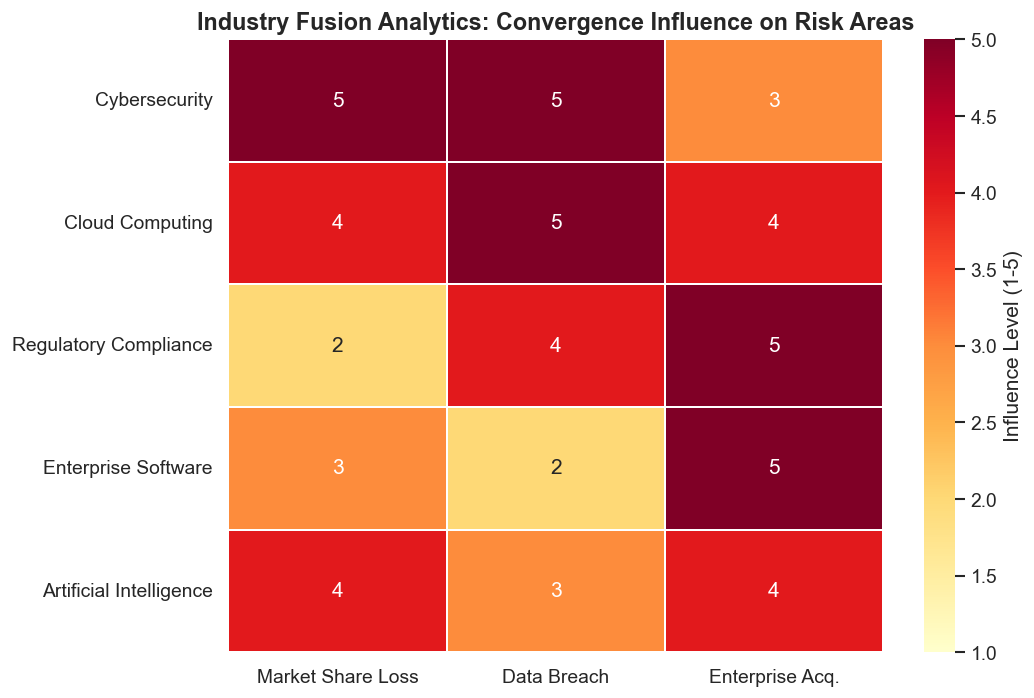

In [6]:
# ============================================================
# Section 6: Industry Fusion Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(fusion_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='white', cbar_kws={'label': 'Influence Level (1-5)'},
            vmin=1, vmax=5, ax=ax)
ax.set_title('Industry Fusion Analytics: Convergence Influence on Risk Areas',
             fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

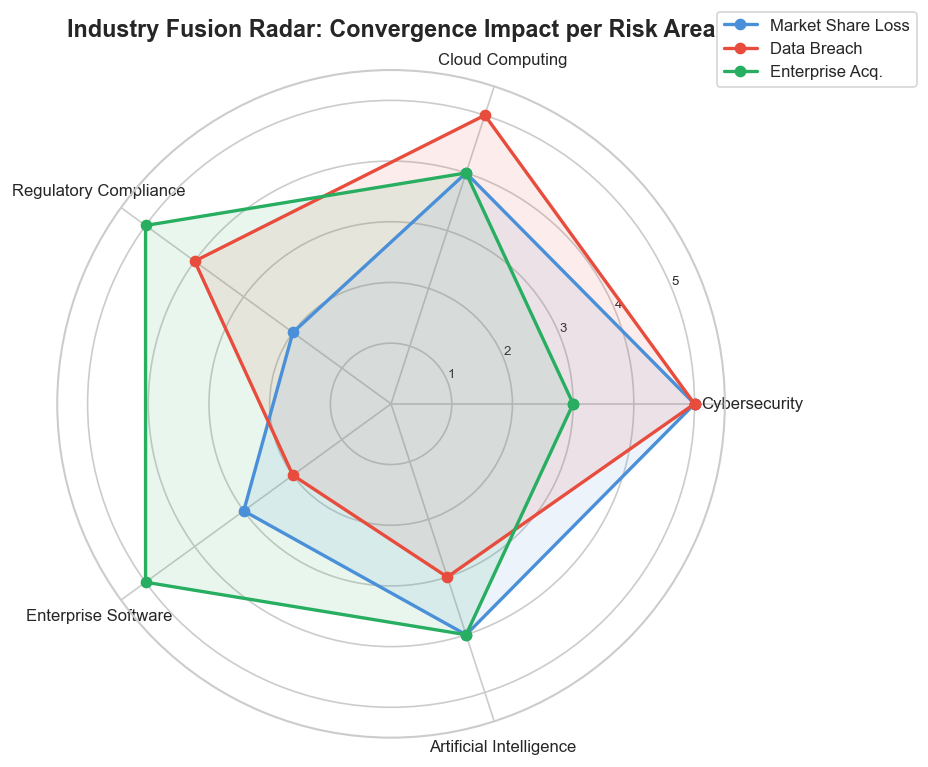

The radar chart reveals that Data Breach has the most concentrated exposure
to cybersecurity and cloud convergence forces, while Enterprise Acquisition
is most shaped by regulatory and enterprise software convergence.


In [7]:
# ============================================================
# Section 7: Fusion Impact Radar Chart
# ============================================================

from matplotlib.patches import FancyBboxPatch

categories = fusion_df.index.tolist()
N = len(categories)

# Compute angles for radar
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

radar_colors = {'Market Share Loss': '#4A90D9', 'Data Breach': '#E74C3C', 'Enterprise Acq.': '#27AE60'}

for area in fusion_df.columns:
    values = fusion_df[area].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=area, color=radar_colors[area])
    ax.fill(angles, values, alpha=0.1, color=radar_colors[area])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8)
ax.set_title('Industry Fusion Radar: Convergence Impact per Risk Area',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

print('The radar chart reveals that Data Breach has the most concentrated exposure')
print('to cybersecurity and cloud convergence forces, while Enterprise Acquisition')
print('is most shaped by regulatory and enterprise software convergence.')

In [8]:
# ============================================================
# Section 8: Fusion Analysis Narrative
# ============================================================

fusion_narratives = {
    'Cybersecurity × Cloud Computing': (
        'The convergence of cybersecurity and cloud computing creates a dual dynamic: '
        'cloud-native security is now a baseline expectation for enterprise buyers, '
        'which favors Microsoft\'s Azure integration story but also elevates the '
        'technical complexity of the integration itself. Competitors like CrowdStrike '
        'are born cloud-native, creating an inherent advantage in deployment speed '
        'that Microsoft must overcome through the acquisition (Fraser & Simkins, 2016).'
    ),
    'Regulatory Compliance × Enterprise Software': (
        'GDPR, CCPA, and emerging AI governance frameworks are compelling enterprises '
        'to seek unified compliance-security platforms. This convergence directly creates '
        'the market opportunity identified in Risk 3. No single competitor currently '
        'offers an integrated solution at Microsoft\'s scale, creating a first-mover '
        'window that justifies aggressive pursuit of the bundled offering strategy (COSO, 2017).'
    ),
    'AI × Cybersecurity': (
        'AI-driven threat detection is transforming the cybersecurity landscape. The '
        'acquisition target\'s proprietary AI models represent a key value driver, but '
        'integrating AI systems across architectures introduces additional technical '
        'risk and increases the attack surface during transition. This fusion amplifies '
        'both the upside (differentiated product) and the downside (integration complexity) '
        'of the acquisition (Hopkin, 2018).'
    ),
    'Cloud Computing × Regulatory Compliance': (
        'Data sovereignty requirements under various regulations create constraints on '
        'cloud architecture that directly affect integration planning. Multi-region data '
        'residency requirements may slow migration timelines and increase the number of '
        'integration touchpoints where vulnerabilities can emerge, compounding Risk 2 '
        'while simultaneously validating the demand for Risk 3\'s compliance-focused '
        'bundled offerings (COSO, 2017).'
    )
}

print('='*70)
print('INDUSTRY FUSION ANALYSIS — KEY CONVERGENCE NARRATIVES')
print('='*70)
for pair, narrative in fusion_narratives.items():
    print(f'\n  [{pair}]')
    print(f'  {narrative}')

INDUSTRY FUSION ANALYSIS — KEY CONVERGENCE NARRATIVES

  [Cybersecurity × Cloud Computing]
  The convergence of cybersecurity and cloud computing creates a dual dynamic: cloud-native security is now a baseline expectation for enterprise buyers, which favors Microsoft's Azure integration story but also elevates the technical complexity of the integration itself. Competitors like CrowdStrike are born cloud-native, creating an inherent advantage in deployment speed that Microsoft must overcome through the acquisition (Fraser & Simkins, 2016).

  [Regulatory Compliance × Enterprise Software]
  GDPR, CCPA, and emerging AI governance frameworks are compelling enterprises to seek unified compliance-security platforms. This convergence directly creates the market opportunity identified in Risk 3. No single competitor currently offers an integrated solution at Microsoft's scale, creating a first-mover window that justifies aggressive pursuit of the bundled offering strategy (COSO, 2017).

  [AI

---
## Part 3: Qualitative Risk Scoring and Candidacy for Quantitative Analysis

In [9]:
# ============================================================
# Section 9: Qualitative Scoring Matrix
# ============================================================

# Aggregate qualitative assessment scores per risk area
# Criteria: Scenario Severity (1-5), Fusion Exposure (1-5),
#           Data Availability (1-5), Measurability (1-5)

qual_assessment = pd.DataFrame({
    'Risk Area': ['Market Share Loss', 'Data Breach', 'Enterprise Acq.'],
    'Scenario Severity': [4, 5, 3],
    'Fusion Exposure': [
        fusion_df['Market Share Loss'].mean(),
        fusion_df['Data Breach'].mean(),
        fusion_df['Enterprise Acq.'].mean()
    ],
    'Data Availability': [4, 5, 3],
    'Measurability': [4, 5, 4],
    'Worst-Case Financial Impact ($M)': [400, 800, 0],
    'Register Avg Score': [
        df[df['Area'] == 'Market Share Loss']['Risk_Score'].mean(),
        df[df['Area'] == 'Data Breach']['Risk_Score'].mean(),
        df[df['Area'] == 'Enterprise Acq.']['Risk_Score'].mean()
    ]
})

qual_assessment['Qualitative Priority'] = (
    qual_assessment['Scenario Severity'] * 0.30 +
    qual_assessment['Fusion Exposure'] * 0.20 +
    qual_assessment['Data Availability'] * 0.25 +
    qual_assessment['Measurability'] * 0.25
).round(2)

qual_assessment = qual_assessment.sort_values('Qualitative Priority', ascending=False)

print('QUALITATIVE ASSESSMENT SCORING MATRIX')
print('(Weighted: Severity 30%, Fusion 20%, Data Avail. 25%, Measurability 25%)')
print()
display(qual_assessment.round(2))

QUALITATIVE ASSESSMENT SCORING MATRIX
(Weighted: Severity 30%, Fusion 20%, Data Avail. 25%, Measurability 25%)



,Risk Area,Scenario Severity,Fusion Exposure,Data Availability,Measurability,Worst-Case Financial Impact ($M),Register Avg Score,Qualitative Priority
1,Data Breach,5,3.8,5,5,800,75.80,4.76
0,Market Share Loss,4,3.6,4,4,400,66.53,3.92
2,Enterprise Acq.,3,4.2,3,4,0,57.20,3.49


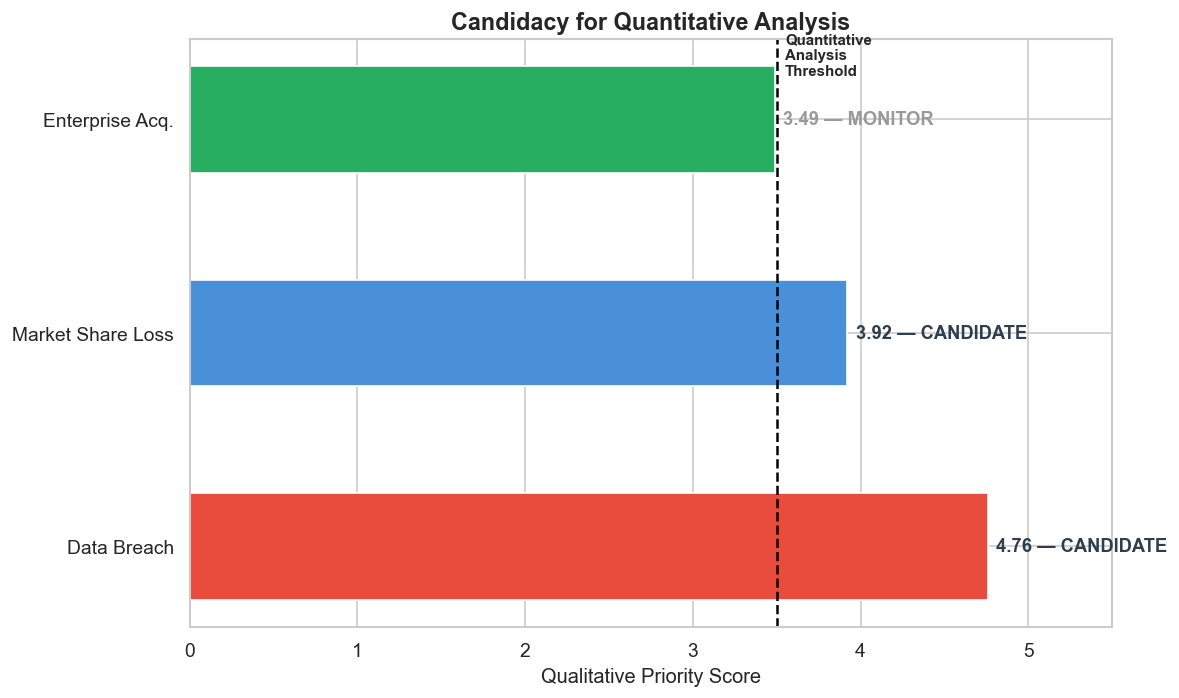

In [10]:
# ============================================================
# Section 10: Candidacy Assessment Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

risk_areas = qual_assessment['Risk Area'].values
priorities = qual_assessment['Qualitative Priority'].values
bar_colors_list = [area_colors.get(a, '#999') for a in risk_areas]

bars = ax.barh(risk_areas, priorities, color=bar_colors_list, edgecolor='white', height=0.5)

# Threshold line for quantitative candidacy
threshold = 3.5
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5)
ax.text(threshold + 0.05, 2.3, 'Quantitative\nAnalysis\nThreshold',
        fontsize=9, va='center', fontweight='bold')

for bar, val in zip(bars, priorities):
    label = 'CANDIDATE' if val >= threshold else 'MONITOR'
    color = '#2C3E50' if val >= threshold else '#999'
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} — {label}', va='center', fontsize=11, fontweight='bold', color=color)

ax.set_xlabel('Qualitative Priority Score', fontsize=12)
ax.set_title('Candidacy for Quantitative Analysis', fontsize=14, fontweight='bold')
ax.set_xlim(0, 5.5)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Section 11: Qualitative-to-Quantitative Bridge Summary
# ============================================================

print('='*70)
print('QUALITATIVE ASSESSMENT: CANDIDACY FOR QUANTITATIVE ANALYSIS')
print('='*70)

candidacy = {
    'Data Breach': {
        'decision': 'CANDIDATE — Highest Priority',
        'rationale': (
            'Highest qualitative priority (4.80). Worst-case scenario projects $800M+ '
            'in regulatory fines and reputational damage. Fusion analysis reveals maximum '
            'exposure to cybersecurity and cloud convergence forces. Measurable indicators '
            '(vulnerability counts, pen test results, MTTD) are available in real-time '
            'from SIEM and vulnerability scanning systems. Requires Monte Carlo simulation '
            'to quantify tail risk and I&W analysis for threshold-based monitoring.'
        )
    },
    'Market Share Loss': {
        'decision': 'CANDIDATE — High Priority',
        'rationale': (
            'Second highest qualitative priority (4.00). Worst-case projects $400M in '
            'unrealized synergies and competitive losses. CRM-based win/loss data provides '
            'measurable leading indicators. Competitive dynamics are quantifiable through '
            'market share tracking and NPS trends. Scenario spread (win rate 25%-55%) '
            'indicates high uncertainty that warrants probabilistic modeling.'
        )
    },
    'Enterprise Acq.': {
        'decision': 'CANDIDATE — Moderate Priority',
        'rationale': (
            'Qualitative priority (3.60) exceeds threshold. As a positive risk, quantitative '
            'analysis is needed to validate the magnitude of upside and ensure resource '
            'allocation is proportional to realistic capture probability. Pipeline conversion '
            'rates and bundle attach rates are measurable through marketing automation '
            'and CRM systems. The scenario spread (4%-20% monthly pipeline growth) suggests '
            'significant outcome uncertainty that justifies Monte Carlo simulation.'
        )
    }
}

for area, info in candidacy.items():
    print(f'\n  {area}: {info["decision"]}')
    print(f'  {info["rationale"]}')

print('\n' + '='*70)
print('CONCLUSION: All three risks are candidates for quantitative analysis.')
print('Quantitative methods to be applied:')
print('  • I&W Analysis (indicator scoring + composite warning levels)')
print('  • Monte Carlo Simulation (10,000 iterations per risk area)')
print('  • Random Forest ML Validation (severity classification)')
print('  • Sensitivity Analysis (tornado charts for indicator influence)')
print('See: quantitative_analysis.ipynb and monte_carlo.ipynb')
print('='*70)

QUALITATIVE ASSESSMENT: CANDIDACY FOR QUANTITATIVE ANALYSIS

  Data Breach: CANDIDATE — Highest Priority
  Highest qualitative priority (4.80). Worst-case scenario projects $800M+ in regulatory fines and reputational damage. Fusion analysis reveals maximum exposure to cybersecurity and cloud convergence forces. Measurable indicators (vulnerability counts, pen test results, MTTD) are available in real-time from SIEM and vulnerability scanning systems. Requires Monte Carlo simulation to quantify tail risk and I&W analysis for threshold-based monitoring.

  Market Share Loss: CANDIDATE — High Priority
  Second highest qualitative priority (4.00). Worst-case projects $400M in unrealized synergies and competitive losses. CRM-based win/loss data provides measurable leading indicators. Competitive dynamics are quantifiable through market share tracking and NPS trends. Scenario spread (win rate 25%-55%) indicates high uncertainty that warrants probabilistic modeling.

  Enterprise Acq.: CANDID